<a href="https://colab.research.google.com/github/Adhityayusuf/mesin-learning/blob/main/KUIS1_244107020045_M_Adhitya_Yusuf_Al_Ayyubi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [10]:
print("--- 1. Inspeksi Profile Data ---")
df.info()
print("\n--- 2. Variabel dengan Missing Value ---")
missing_values = df.isnull().sum()
variabel_hilang = missing_values[missing_values > 0]
print(variabel_hilang)

--- 1. Inspeksi Profile Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

--- 2. Variabel dengan Missing Value ---
workclass         

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [11]:
modus_workclass = df['workclass'].mode()[0]
modus_occupation = df['occupation'].mode()[0]
modus_native_country = df['native-country'].mode()[0]
df['workclass'] = df['workclass'].fillna(modus_workclass)
df['occupation'] = df['occupation'].fillna(modus_occupation)
df['native-country'] = df['native-country'].fillna(modus_native_country)
print("Proses imputasi selesai dilakukan menggunakan nilai Modus.")
print("\n--- Pengecekan Missing Value Setelah Imputasi ---")
cek_missing = df.isnull().sum()
print(cek_missing)

Proses imputasi selesai dilakukan menggunakan nilai Modus.

--- Pengecekan Missing Value Setelah Imputasi ---
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [18]:
kolom_kualitatif = df.select_dtypes(include=['object']).columns
for col in kolom_kualitatif:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace('?', 'Others')
print(df['workclass'].unique())
df['income'] = df['income'].str.replace('.', '', regex=False)
print(df['income'].unique())

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Others' 'Self-emp-inc' 'Without-pay' 'Never-worked']
['<=50K' '>50K']


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

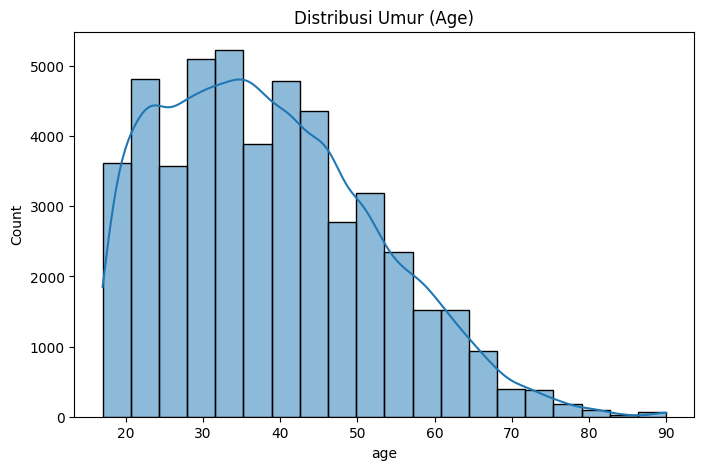

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title('Distribusi Umur (Age)')
plt.show()

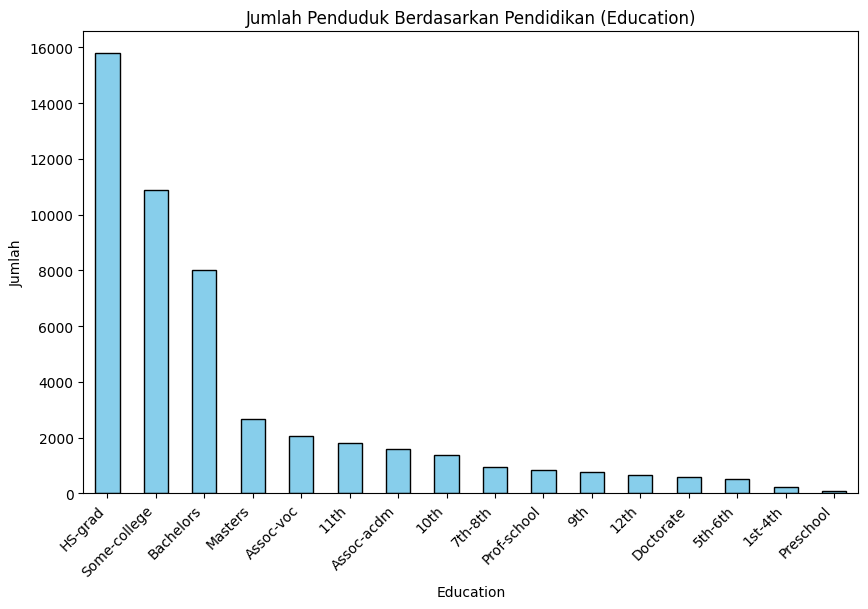

In [20]:
plt.figure(figsize=(10, 6))
df['education'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Jumlah Penduduk Berdasarkan Pendidikan (Education)')
plt.xlabel('Education')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_2790/2732919181.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2')


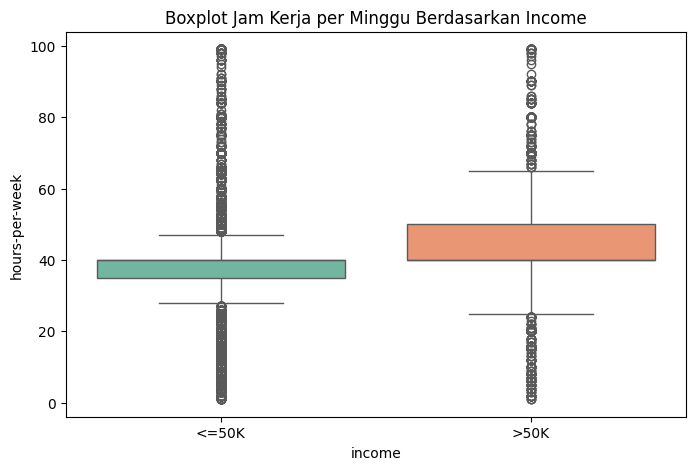

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2')
plt.title('Boxplot Jam Kerja per Minggu Berdasarkan Income')
plt.show()

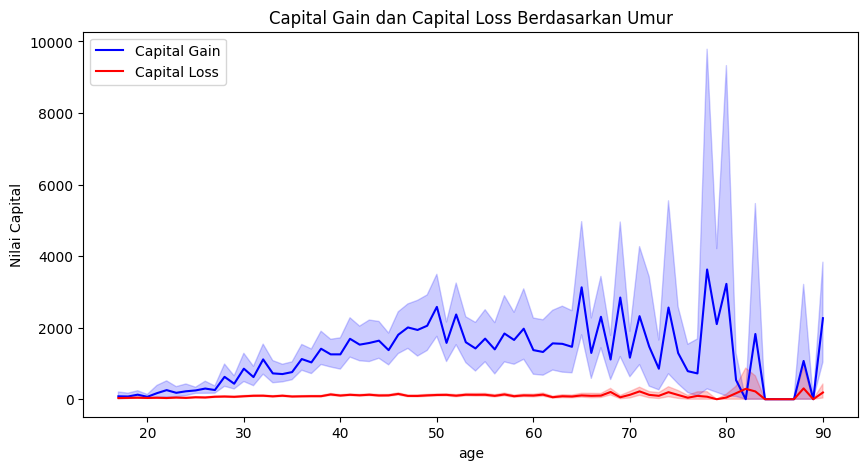

In [22]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='age', y='capital-gain', label='Capital Gain', color='blue')
sns.lineplot(data=df, x='age', y='capital-loss', label='Capital Loss', color='red')
plt.title('Capital Gain dan Capital Loss Berdasarkan Umur')
plt.ylabel('Nilai Capital')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [24]:
'''
1. Distribusi datanya right-skewed. Artinya mayoritas data numpuk di usia muda sekitar 20-40 tahunan, dan makin bertambah usia jumlah datanya makin sedikit.
2. Bakal pakai nilai Median. Alasannya karena distribusi 'age' tadi bentuknya skewed dan pasti ada outlier di usia tua. Nilai Median itu lebih tahan terhadap outlier dibandingkan kalau kita pakai Mean yang gampang ketarik sama nilai ekstrem.
3. Dari boxplot kelihatan jelas kalau kategori income '<=50K' titik outliernya jauh lebih banyak daripada yang '>50K'. Jadi kategori '<=50K' yang paling banyak outliernya (banyak orang yang jam kerjanya kerendahan atau ketinggian banget dari batas normal).
'''

"\n1. Distribusi datanya right-skewed. Artinya mayoritas data numpuk di usia muda sekitar 20-40 tahunan, dan makin bertambah usia jumlah datanya makin sedikit.\n2. Bakal pakai nilai Median. Alasannya karena distribusi 'age' tadi bentuknya skewed dan pasti ada outlier di usia tua. Nilai Median itu lebih tahan terhadap outlier dibandingkan kalau kita pakai Mean yang gampang ketarik sama nilai ekstrem.\n3. Dari boxplot kelihatan jelas kalau kategori income '<=50K' titik outliernya jauh lebih banyak daripada yang '>50K'. Jadi kategori '<=50K' yang paling banyak outliernya (banyak orang yang jam kerjanya kerendahan atau ketinggian banget dari batas normal).\n"

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['income'] = le.fit_transform(df['income'])
df[['sex', 'income']].head()

,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

Korelasi fitur terhadap Income:
 income            1.000000
education-num     0.332613
age               0.230369
hours-per-week    0.227687
capital-gain      0.223013
capital-loss      0.147554
Name: income, dtype: float64


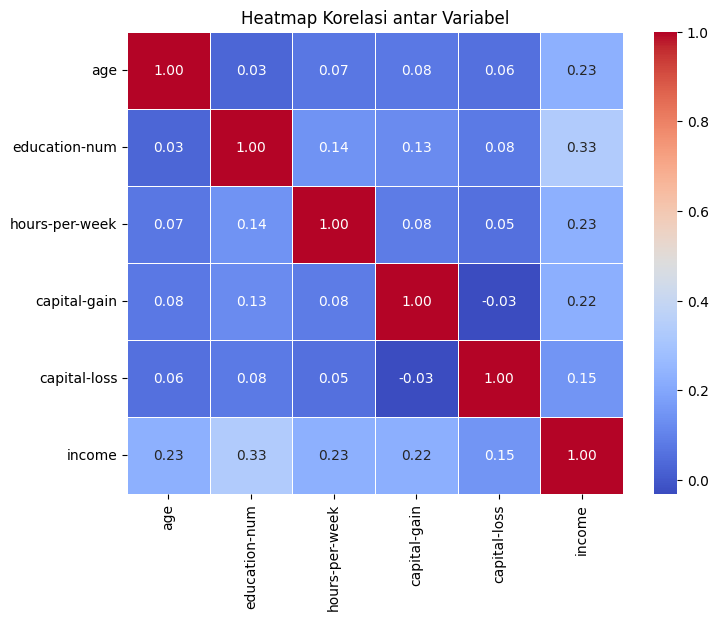

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
kolom_korelasi = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']
korelasi = df[kolom_korelasi].corr()
print("Korelasi fitur terhadap Income:\n", korelasi['income'].sort_values(ascending=False))
plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi antar Variabel')
plt.show()

In [26]:
'''
Berdasarkan hasil korelasi di atas, ini yang bisa diinterpretasikan:

1. 'education-num' punya korelasi positif paling tinggi terhadap 'income' dibandingkan variabel lain. Artinya, pendidikan itu faktor yang paling ngaruh; makin tinggi pendidikannya, makin besar peluang gajinya di atas 50K.
2. 'age' dan 'hours-per-week' juga punya korelasi positif yang lumayan. Ini masuk akal karena orang yang lebih senior secara umur atau yang jam kerjanya lebih banyak rata-rata pendapatannya lebih tinggi.
3. 'capital-gain' dan 'capital-loss' juga berbanding lurus dengan income, tapi pengaruhnya nggak segede pendidikan atau umur.
4. Kesimpulan utamanya: semua variabel yang diuji ini sifatnya berbanding lurus sama pendapatan.
'''

"\nBerdasarkan hasil korelasi di atas, ini yang bisa diinterpretasikan:\n\n1. 'education-num' punya korelasi positif paling tinggi terhadap 'income' dibandingkan variabel lain. Artinya, pendidikan itu faktor yang paling ngaruh; makin tinggi pendidikannya, makin besar peluang gajinya di atas 50K.\n2. 'age' dan 'hours-per-week' juga punya korelasi positif yang lumayan. Ini masuk akal karena orang yang lebih senior secara umur atau yang jam kerjanya lebih banyak rata-rata pendapatannya lebih tinggi.\n3. 'capital-gain' dan 'capital-loss' juga berbanding lurus dengan income, tapi pengaruhnya nggak segede pendidikan atau umur.\n4. Kesimpulan utamanya: semua variabel yang diuji ini sifatnya berbanding lurus sama pendapatan.\n"

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [27]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


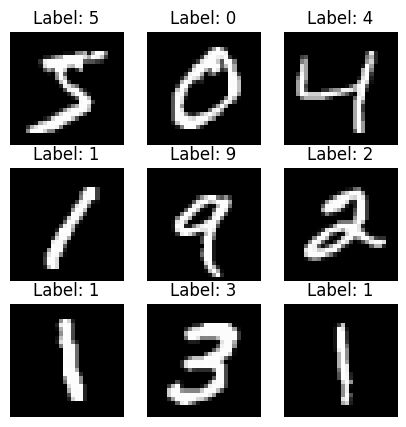

In [28]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Shape setelah upsampling: (10000, 32, 32)


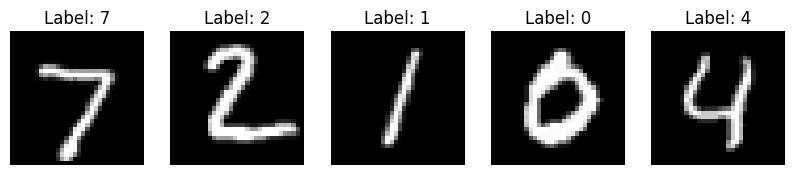

In [31]:
import cv2
import numpy as np
X_test_upsampled = np.empty((len(X_test), 32, 32), dtype=X_test.dtype)
for i in range(len(X_test)):
    X_test_upsampled[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_CUBIC)
print("Shape setelah upsampling:", X_test_upsampled.shape)
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [32]:
X_test_norm = X_test_upsampled.astype('float32') / 255.0
print("Nilai pixel terkecil :", X_test_norm.min())
print("Nilai pixel terbesar :", X_test_norm.max())

Nilai pixel terkecil : 0.0
Nilai pixel terbesar : 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [33]:
X_test_flat = np.empty((len(X_test_norm), 1024), dtype=X_test_norm.dtype)
for i in range(len(X_test_norm)):
    X_test_flat[i] = X_test_norm[i].flatten()
print("Shape awal :", X_test_norm.shape)
print("Shape baru :", X_test_flat.shape)

Shape awal : (10000, 32, 32)
Shape baru : (10000, 1024)
